# BÀI TẬP: EDA HOÀN CHỈNH — TITANIC
## Data Profiling → Descriptive Statistics → Define the Question
**Nguồn:** kaggle.com/c/titanic (891 dòng)

```
PHẦN A — DATA PROFILING       : dữ liệu sạch chưa, có gì
PHẦN B — DESCRIPTIVE STATS    : từng biến trông như thế nào
PHẦN C — DEFINE THE QUESTION  : đặt câu hỏi kinh doanh, trả lời bằng code, rút insight
```

## Setup

In [8]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [9]:
# TODO
print(df.size)
df.columns
df.dtypes

13365


,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object


## A.2. Missing values & Duplicate data

In [10]:
# TODO
df.isnull()
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
886,True
887,False
888,False
889,False


## A.3. Invalid values

In [11]:
# TODO
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [12]:
# TODO
df['family_size']= df['sibsp'] + df['parch'] +1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [13]:
# TODO
for col in ['age', 'fare', 'family_size']:
    print(col, '| mean:', df[col].mean(), '| median:', df[col].median(), '| mode:', df[col].mode()[0])

age | mean: 29.69911764705882 | median: 28.0 | mode: 24.0
fare | mean: 32.204207968574636 | median: 14.4542 | mode: 8.05
family_size | mean: 1.904601571268238 | median: 1.0 | mode: 1


## Group 2 — Dispersion

In [14]:
# TODO
for col in ['age', 'fare', 'family_size']:
    print(col, '| std:', df[col].std(), '| var:', df[col].var(),
          '| range:', df[col].max()-df[col].min(),
          '| IQR:', df[col].quantile(0.75)-df[col].quantile(0.25))

age | std: 14.526497332334044 | var: 211.0191247463081 | range: 79.58 | IQR: 17.875
fare | std: 49.693428597180905 | var: 2469.436845743117 | range: 512.3292 | IQR: 23.0896
family_size | std: 1.6134585413550788 | var: 2.6032484646716587 | range: 10 | IQR: 1.0


## Group 3 — Location and Shape

age | skewness: 0.38910778230082704 | kurtosis: 0.17827415364210353
0.25    20.125
0.50    28.000
0.75    38.000
Name: age, dtype: float64
fare | skewness: 4.787316519674893 | kurtosis: 33.39814088089868
0.25     7.9104
0.50    14.4542
0.75    31.0000
Name: fare, dtype: float64


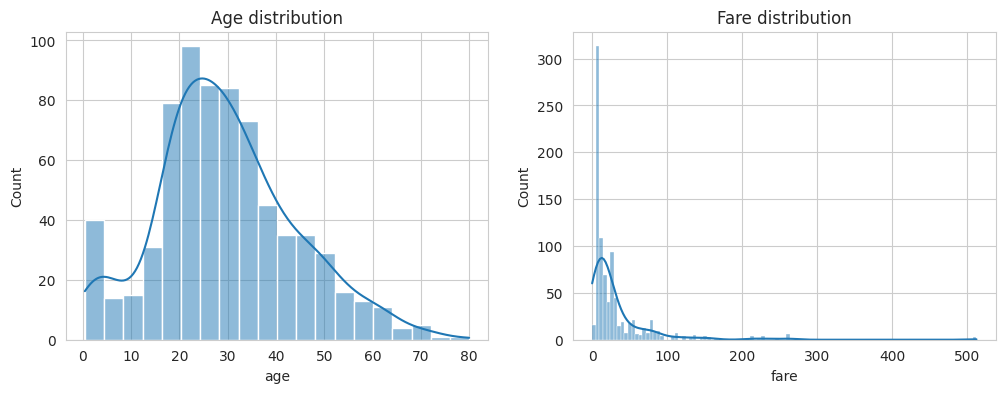

In [15]:
# TODO
for col in ['age', 'fare']:
    print(col, '| skewness:', df[col].skew(), '| kurtosis:', df[col].kurt())
    print(df[col].quantile([0.25, 0.5, 0.75]))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['age'].dropna(), kde=True, ax=axes[0]).set_title('Age distribution')
sns.histplot(df['fare'], kde=True, ax=axes[1]).set_title('Fare distribution')
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

age | skewness: 0.38910778230082704 | kurtosis: 0.17827415364210353
0.25    20.125
0.50    28.000
0.75    38.000
Name: age, dtype: float64
fare | skewness: 4.787316519674893 | kurtosis: 33.39814088089868
0.25     7.9104
0.50    14.4542
0.75    31.0000
Name: fare, dtype: float64


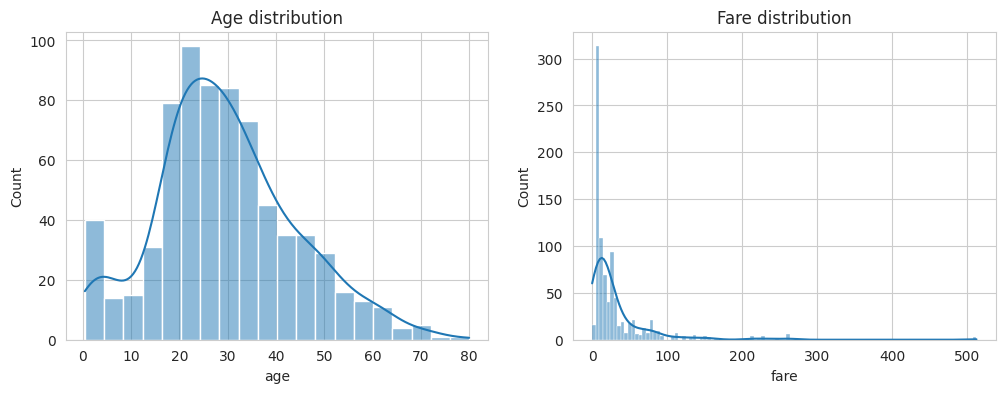

In [16]:
for col in ['age', 'fare']:
    print(col, '| skewness:', df[col].skew(), '| kurtosis:', df[col].kurt())
    print(df[col].quantile([0.25, 0.5, 0.75]))
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['age'].dropna(), kde=True, ax=axes[0]).set_title('Age distribution')
sns.histplot(df['fare'], kde=True, ax=axes[1]).set_title('Fare distribution')
plt.show()

## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


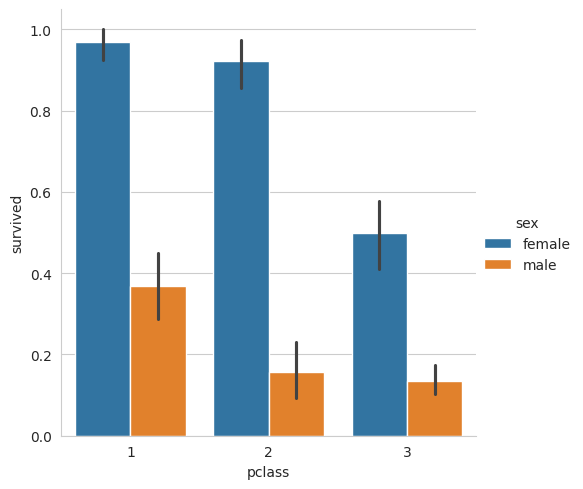

In [17]:
# TODO
print(df.groupby('sex')['survived'].mean())
print(df.groupby('pclass')['survived'].mean())
sns.catplot(x='pclass', y='survived', hue='sex', kind='bar', data=df)

## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

TtestResult(statistic=np.float64(-7.939191660871055), pvalue=np.float64(6.120189341924198e-15), df=np.float64(889.0))

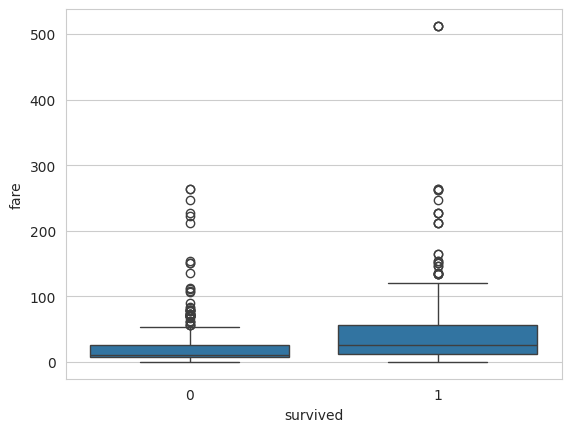

In [18]:
# TODO
df.groupby('survived')['fare'].mean()
sns.boxplot(x='survived', y='fare', data=df)
from scipy.stats import ttest_ind
g0 = df[df['survived']==0]['fare'].dropna()
g1 = df[df['survived']==1]['fare'].dropna()
stats.ttest_ind(g0, g1)

## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

<Axes: xlabel='family_size', ylabel='survived'>

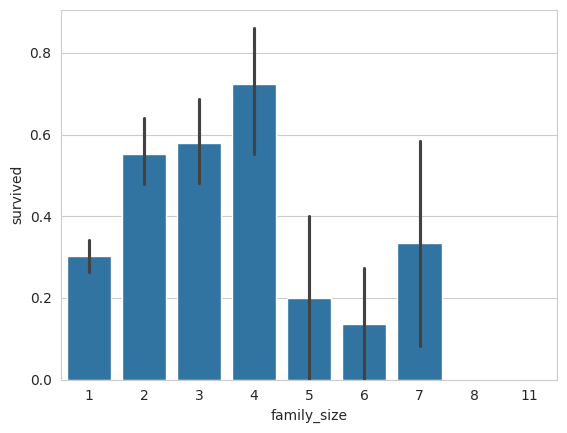

In [19]:
# TODO
df.groupby('family_size')['survived'].mean()
sns.barplot(x='family_size', y='survived', data=df)

## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

<Axes: xlabel='embark_town', ylabel='survived'>

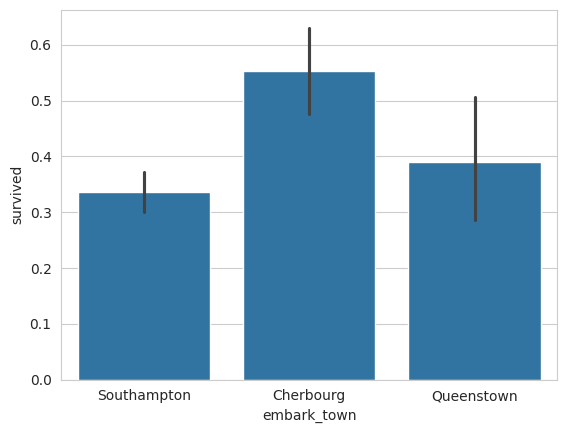

In [21]:
# TODO
df.groupby('embark_town')['survived'].mean().sort_values(ascending=False)
sns.barplot(x='embark_town', y='survived', data=df)

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

Chất lượng dữ liệu .

Đặc điểm phân phối age/fare .

Yếu tố ảnh hưởng sống sót mạnh nhất .

Vai trò của fare và family_size.

Một lưu ý về nhiễu/tương quan giả